In [1]:
import pandas as pd
port_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
port_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [2]:
port_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [4]:
port_df.shape

(322, 8)

In [5]:
port_df.isnull().sum()

amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [6]:
port_df.duplicated().sum()

np.int64(0)

In [7]:
port_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

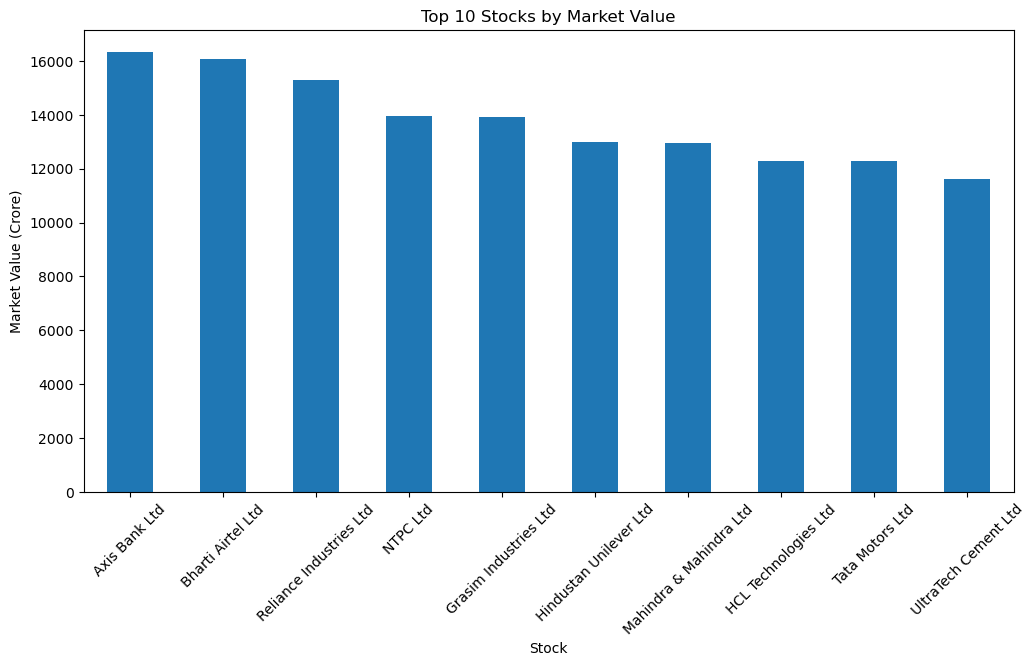

In [8]:
import matplotlib.pyplot as plt

top = port_df.groupby('stock_name')['market_value_cr'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top.plot(kind='bar')

plt.title("Top 10 Stocks by Market Value")
plt.xlabel("Stock")
plt.ylabel("Market Value (Crore)")
plt.xticks(rotation=45)
plt.show()

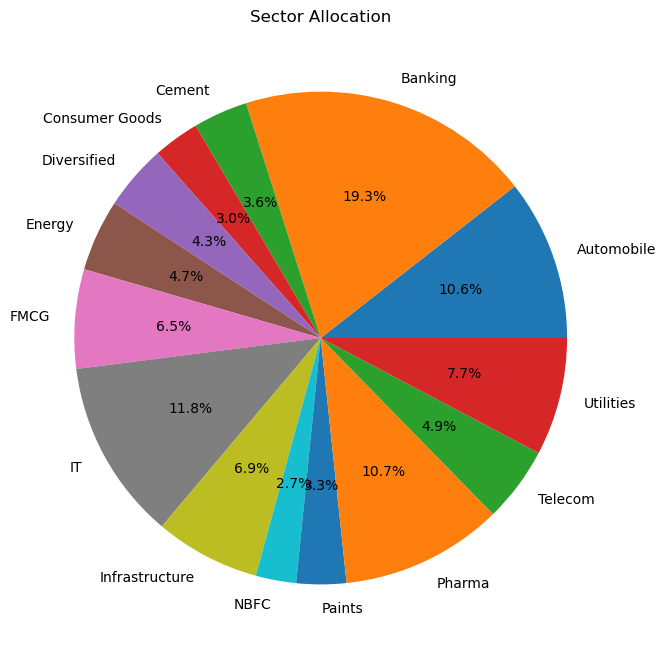

In [9]:
sector = port_df.groupby('sector')['market_value_cr'].sum()

plt.figure(figsize=(8,8))
sector.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sector Allocation")
plt.ylabel("")
plt.show()

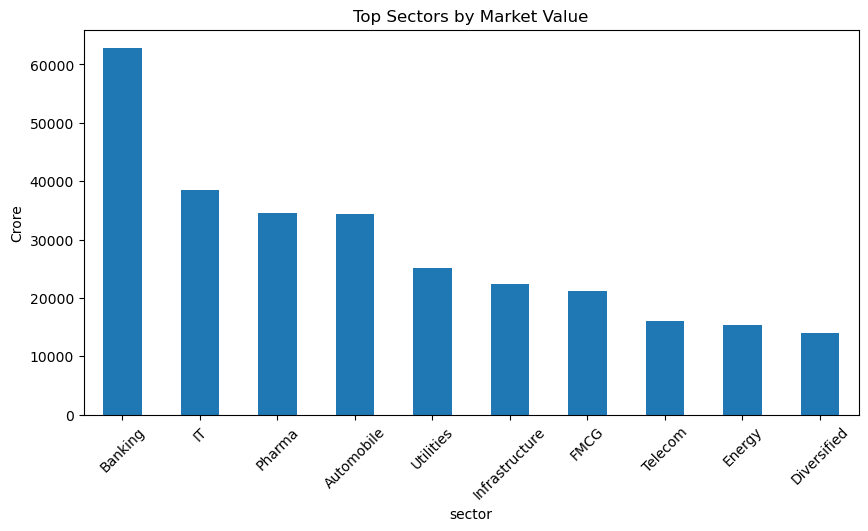

In [10]:
sector = port_df.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sector.head(10).plot(kind='bar')

plt.title("Top Sectors by Market Value")
plt.ylabel("Crore")
plt.xticks(rotation=45)
plt.show()

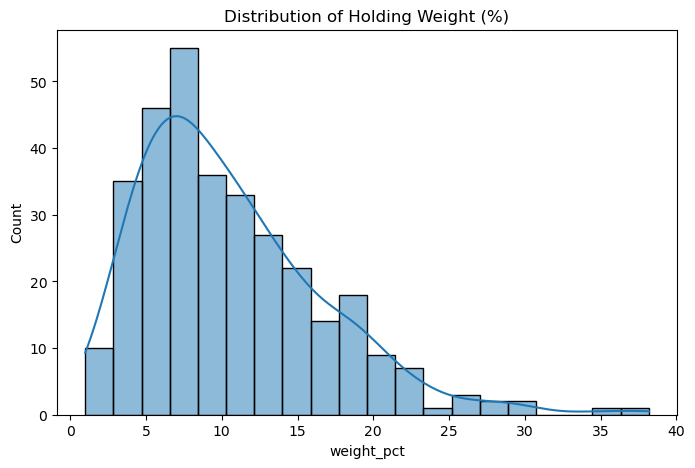

In [11]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    port_df['weight_pct'],
    bins=20,
    kde=True
)

plt.title("Distribution of Holding Weight (%)")
plt.show()

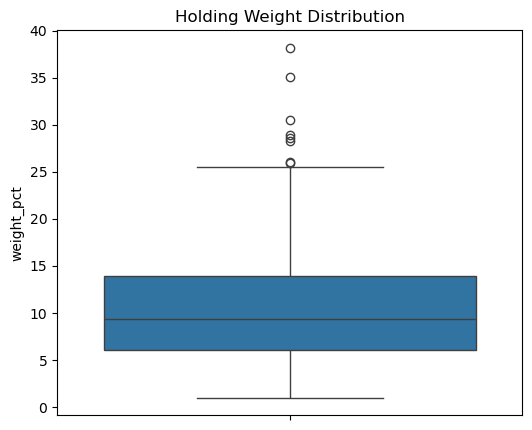

In [12]:
plt.figure(figsize=(6,5))

sns.boxplot(y=port_df['weight_pct'])

plt.title("Holding Weight Distribution")
plt.show()

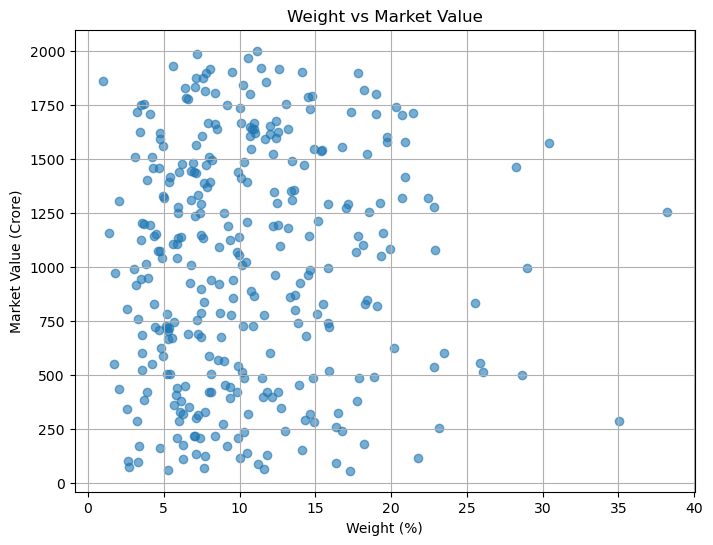

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    port_df['weight_pct'],
    port_df['market_value_cr'],
    alpha=0.6
)

plt.xlabel("Weight (%)")
plt.ylabel("Market Value (Crore)")
plt.title("Weight vs Market Value")
plt.grid(True)
plt.show()

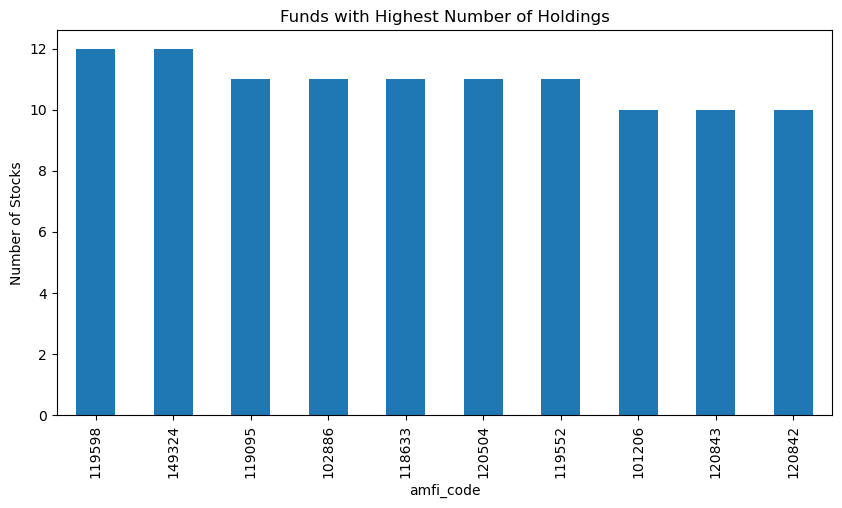

In [14]:
top = port_df.groupby('amfi_code')['stock_symbol'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top.plot(kind='bar')

plt.title("Funds with Highest Number of Holdings")
plt.ylabel("Number of Stocks")
plt.show()

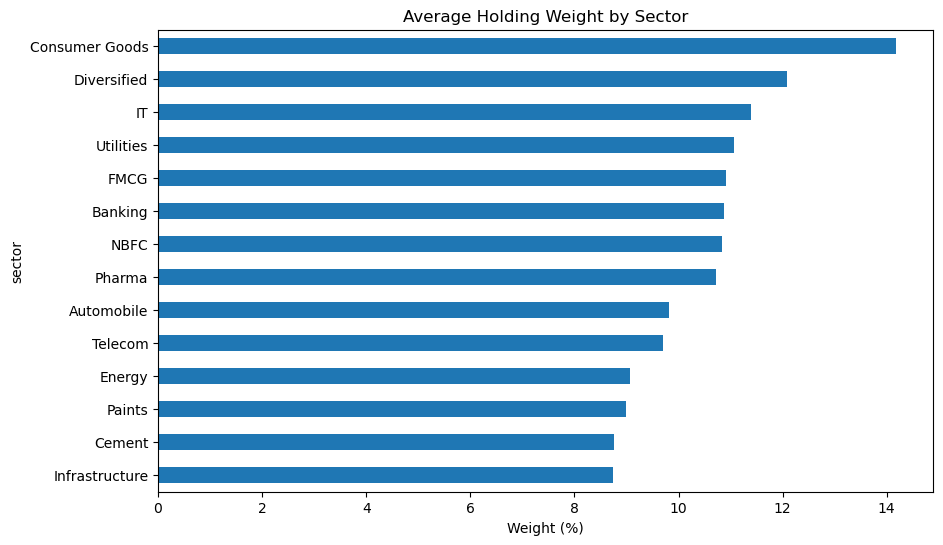

In [15]:
avg = port_df.groupby('sector')['weight_pct'].mean().sort_values()

plt.figure(figsize=(10,6))
avg.plot(kind='barh')

plt.title("Average Holding Weight by Sector")
plt.xlabel("Weight (%)")
plt.show()

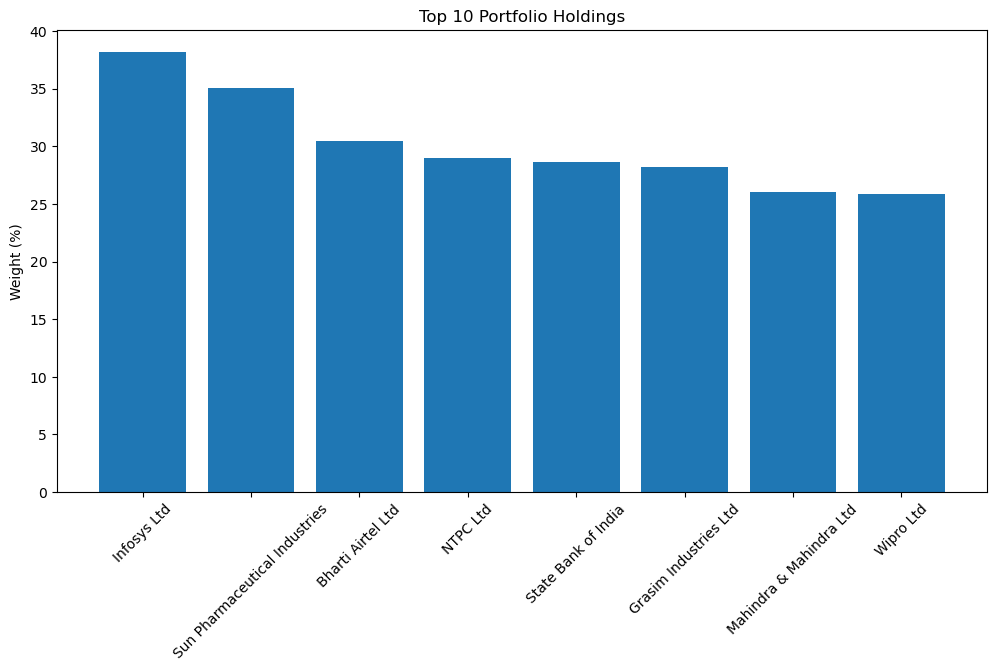

In [16]:
top = port_df.sort_values(
    'weight_pct',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top['stock_name'],
    top['weight_pct']
)

plt.xticks(rotation=45)

plt.title("Top 10 Portfolio Holdings")
plt.ylabel("Weight (%)")

plt.show()

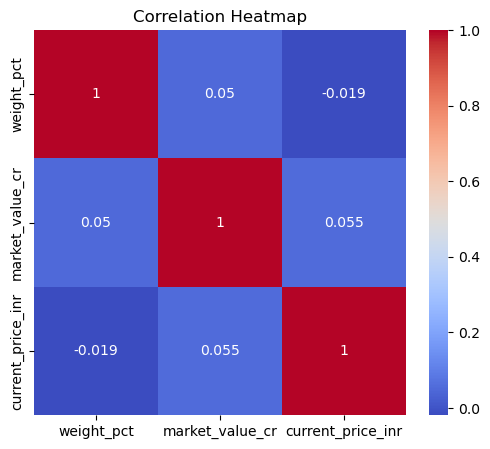

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(
    port_df[['weight_pct',
             'market_value_cr',
             'current_price_inr']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()